# 3D workspace visualization for the Kinematics repository.

### What it shows:

- Reachable gripper-center positions based on configured link lengths and joint limits
- The configured workspace box from configs/kinematics_settings.toml
- One arm pose with shoulder, elbow, wrist, and gripper-center points

### Target pose (optional):

```python tools/visualize_workspace.py --target 250 850 0```

- X = left/right in robot-base coordinates
- Z = front/back in robot-base coordinates
- Y = distance downward from the top reference

In [48]:
from dataclasses import dataclass
from math import radians, cos, sin
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np

from config.config_loader import load_config
from kinematics.inverse_kinematics import calculate_angles


def joint_by_role(servo_config: dict[str, Any], role: str) -> dict[str, Any]:
    """Return the servo joint config matching a kinematic role such as theta1."""
    for joint in servo_config["joints"].values():
        if joint.get("kinematic_role") == role:
            return joint

    raise KeyError(f"No joint with kinematic_role={role!r} found.")

In [49]:
@dataclass(frozen=True)
class RobotConfig:
    """Relevant values loaded from the TOME configuration file."""
    geometry: dict[str, Any]
    settings: dict[str, Any]
    servo: dict[str, Any]

    l1_mm: float
    l2_mm: float
    lg_mm: float
    h0_mm: float

    base_x_mm: float
    base_y_mount_mm: float
    base_z_mm: float
    shoulder_y_mm: float

    approach_angle_deg: float
    bounds: dict[str, float]

    j1_min_deg: float
    j1_max_deg: float
    j2_min_deg: float
    j2_max_deg: float
    j3_min_deg: float
    j3_max_deg: float

    solution_preference: str
    check_side_view_orientation: bool

    @staticmethod
    def from_files() -> "RobotConfig":
        geometry = load_config("robot_geometry.toml")
        settings = load_config("kinematics_settings.toml")
        servo = load_config("servo_calibration.toml")

        model = settings["model"]
        links = geometry["link_lengths_mm"]

        l1 = float(links["L1_shoulder_to_elbow"])
        l2 = float(links["L2_elbow_to_wrist"])

        if model["use_gripper_offset"]:
            lg = float(links[model["selected_Lg_key"]])
        else:
            lg = 0.0

        if model["use_h0_from_robot_geometry"]:
            h0 = float(links[model["selected_h0_key"]])
        else:
            h0 = 0.0

        input_coordinates = settings.get("input_coordinates", {})
        base_origin = input_coordinates.get(
            "base_rotation_axis_at_mounting_plate_mm",
            [0.0, input_coordinates.get("max_height_mm", 0.0), 0.0]
        )

        base_x, base_y_mount, base_z = [float(value) for value in base_origin]
        shoulder_y = base_y_mount - h0

        j1 = joint_by_role(servo, "theta1")
        j2 = joint_by_role(servo, "theta2")
        j3 = joint_by_role(servo, "theta3")

        validation = settings["validation"]

        return RobotConfig(
            geometry=geometry,
            settings=settings,
            servo=servo,
            l1_mm=l1,
            l2_mm=l2,
            lg_mm=lg,
            h0_mm=h0,
            base_x_mm=base_x,
            base_y_mount_mm=base_y_mount,
            base_z_mm=base_z,
            shoulder_y_mm=shoulder_y,
            approach_angle_deg=float(settings["ik"]["default_approach_angle_deg"]),
            bounds={key: float(value) for key, value in settings["workspace_bounds_robot_base_mm"].items()},
            j1_min_deg=float(j1["theta_min_deg"]),
            j1_max_deg=float(j1["theta_max_deg"]),
            j2_min_deg=float(j2["theta_min_deg"]),
            j2_max_deg=float(j2["theta_max_deg"]),
            j3_min_deg=float(j3["theta_min_deg"]),
            j3_max_deg=float(j3["theta_max_deg"]),
            solution_preference=str(settings["ik"]["solution_preference"]),
            check_side_view_orientation=bool(validation.get("check_side_view_orientation", False)),
        )


In [50]:
def arm_points_from_angles(
        cfg: RobotConfig,
        base_deg: float,
        shoulder_deg: float,
        elbow_deg: float,
) -> dict[str, tuple[float, float, float]]:
    """Calculate 3D shoulder, elbow, wrist, and gripper-center points.    """
    base_rad = radians(base_deg)
    shoulder_rad = radians(-shoulder_deg)
    elbow_relative_rad = radians(elbow_deg - 180.0)
    forearm_rad = shoulder_rad + elbow_relative_rad
    approach_rad = radians(cfg.approach_angle_deg)

    # Coordinates in the 2D arm plane before base rotation
    shoulder_r = 0.0
    shoulder_y_math = 0.0

    elbow_r = cfg.l1_mm * cos(shoulder_rad)
    elbow_y_math = cfg.l1_mm * sin(shoulder_rad)

    wrist_r = elbow_r + cfg.l2_mm * cos(forearm_rad)
    wrist_y_math = elbow_y_math + cfg.l2_mm * sin(forearm_rad)

    gripper_r = wrist_r + cfg.lg_mm * cos(approach_rad)
    gripper_y_math = wrist_y_math + cfg.lg_mm * sin(approach_rad)

    def rotate_to_xyz(r_mm: float, y_math_mm: float) -> tuple[float, float, float]:
        x_mm = cfg.base_x_mm + r_mm * cos(base_rad)
        z_mm = cfg.base_z_mm + r_mm * sin(base_rad)
        y_mm = cfg.shoulder_y_mm - y_math_mm

        return x_mm, y_mm, z_mm

    return {
        "shoulder": rotate_to_xyz(shoulder_r, shoulder_y_math),
        "elbow": rotate_to_xyz(elbow_r, elbow_y_math),
        "wrist": rotate_to_xyz(wrist_r, wrist_y_math),
        "gripper": rotate_to_xyz(gripper_r, gripper_y_math),
    }

In [51]:
def sample_reachable_gripper_points(
        cfg: RobotConfig,
        samples_base: int,
        samples_shoulder: int,
        samples_elbow: int,
) -> np.ndarray:
    """Sample gripper-center positions from configured joint limits."""
    base_deg = np.linspace(cfg.j1_min_deg, cfg.j1_max_deg, samples_base)
    shoulder_deg = np.linspace(cfg.j2_min_deg, cfg.j2_max_deg, samples_shoulder)
    elbow_deg = np.linspace(cfg.j3_min_deg, cfg.j3_max_deg, samples_elbow)

    base_grid, shoulder_grid, elbow_grid = np.meshgrid(
        base_deg,
        shoulder_deg,
        elbow_deg,
        indexing='ij'
    )

    base_rad = np.deg2rad(base_grid)
    shoulder_rad = np.deg2rad(-shoulder_grid)
    elbow_relative_rad = np.deg2rad(elbow_grid - 180.0)
    forearm_rad = shoulder_rad + elbow_relative_rad
    approach_rad = np.deg2rad(cfg.approach_angle_deg)

    elbow_r = cfg.l1_mm * np.cos(shoulder_rad)
    elbow_y_math = cfg.l1_mm * np.sin(shoulder_rad)

    wrist_r = elbow_r + cfg.l2_mm * np.cos(forearm_rad)
    wrist_y_math = elbow_y_math + cfg.l2_mm * np.sin(forearm_rad)

    gripper_r = wrist_r + cfg.lg_mm * np.cos(approach_rad)
    gripper_y_math = wrist_y_math + cfg.lg_mm * np.sin(approach_rad)

    x_mm = cfg.base_x_mm + gripper_r * np.cos(base_rad)
    z_mm = cfg.base_z_mm + gripper_r * np.sin(base_rad)
    y_mm = cfg.shoulder_y_mm - gripper_y_math

    valid = np.ones(x_mm.shape, dtype=bool)

    points = np.column_stack(
        (
            x_mm[valid].ravel(),
            y_mm[valid].ravel(),
            z_mm[valid].ravel(),
        )
    )

    return points

In [52]:
def inside_workspace_box(points: np.ndarray, cfg: RobotConfig) -> np.ndarray:
    b = cfg.bounds

    return (
            (points[:, 0] >= b["x_min"])
            & (points[:, 0] <= b["x_max"])
            & (points[:, 1] >= b["y_min"])
            & (points[:, 1] <= b["y_max"])
            & (points[:, 2] >= b["z_min"])
            & (points[:, 2] <= b["z_max"])
    )

In [53]:
def plot_workspace_box(ax, cfg: RobotConfig) -> None:
    """Draw a box representing the configured workspace bounds."""
    b = cfg.bounds

    corners = np.array([
        [b["x_min"], b["z_min"], b["y_min"]],
        [b["x_max"], b["z_min"], b["y_min"]],
        [b["x_max"], b["z_max"], b["y_min"]],
        [b["x_min"], b["z_max"], b["y_min"]],
        [b["x_min"], b["z_min"], b["y_max"]],
        [b["x_max"], b["z_min"], b["y_max"]],
        [b["x_max"], b["z_max"], b["y_max"]],
        [b["x_min"], b["z_max"], b["y_max"]],
    ])

    edges = [
        (0, 1),
        (1, 2),
        (2, 3),
        (3, 0),
        (4, 5),
        (5, 6),
        (6, 7),
        (7, 4),
        (0, 4),
        (1, 5),
        (2, 6),
        (3, 7),
    ]

    for start, end in edges:
        ax.plot(
            [corners[start, 0], corners[end, 0]],
            [corners[start, 1], corners[end, 1]],
            [corners[start, 2], corners[end, 2]],
            linestyle="--",
            linewidth=1.0,
        )

In [54]:
def plot_arm_pose(ax, points: dict[str, tuple[float, float, float]]) -> None:
    """Draw the arm pose with shoulder, elbow, wrist, and gripper."""
    shoulder = np.array(points["shoulder"])
    elbow = np.array(points["elbow"])
    wrist = np.array(points["wrist"])
    gripper = np.array(points["gripper"])

    ax.plot(
        [shoulder[0], elbow[0], wrist[0], gripper[0]],
        [shoulder[1], elbow[1], wrist[1], gripper[1]],
        [shoulder[2], elbow[2], wrist[2], gripper[2]],
        marker="o",
        linewidth=2.0,
        label="Arm pose",
    )

In [55]:
def set_axis_limits(ax: Any, points: np.ndarray, cfg: RobotConfig) -> None:
    """Set plot limits while keeping the Y-down axis readable."""
    b = cfg.bounds

    x_values = np.concatenate(
        [
            points[:, 0],
            np.array([b["x_min"], b["x_max"]]),
        ]
    )
    y_down_values = np.concatenate(
        [
            points[:, 1],
            np.array([b["y_min"], b["y_max"]]),
        ]
    )
    z_values = np.concatenate(
        [
            points[:, 2],
            np.array([b["z_min"], b["z_max"]]),
        ]
    )

    def padded_limits(values: np.ndarray, padding_ratio: float = 0.08) -> tuple[float, float]:
        minimum = float(np.min(values))
        maximum = float(np.max(values))
        span = max(maximum - minimum, 1.0)
        padding = span * padding_ratio
        return minimum - padding, maximum + padding

    x_min, x_max = padded_limits(x_values)
    z_min, z_max = padded_limits(z_values)
    y_min, y_max = padded_limits(y_down_values)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(z_min, z_max)
    ax.set_zlim(y_max, y_min)

L1: 200.0 mm
L2: 164.0 mm
Lg: 124.922 mm
h0: 68.25 mm
Shoulder Y-down coordinate: 931.75 mm
Sampled reachable points: 357911
Reachable points inside configured workspace box: 107258


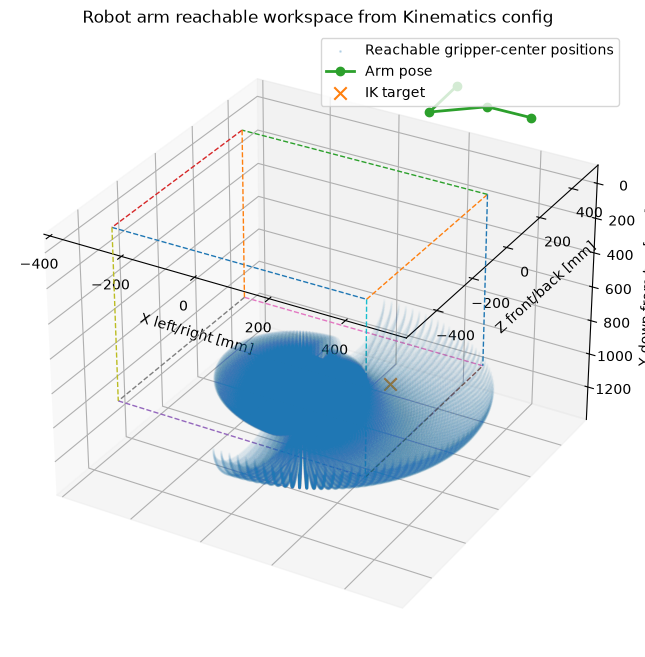

In [56]:
import argparse
import sys

parser = argparse.ArgumentParser()

parser.add_argument(
    "--target",
    nargs=3,
    type=float,
    metavar=("X_MM", "Y_MM", "Z_MM"),
    default=(250.0, 850.0, 0.0),
    help="Target XYZ for the displayed arm pose. Default: 250 850 0",
)
parser.add_argument("--samples-base", type=int, default=71)
parser.add_argument("--samples-shoulder", type=int, default=71)
parser.add_argument("--samples-elbow", type=int, default=71)
parser.add_argument(
    "--show-inside-only",
    action="store_true",
    help="Only plot reachable points that are also inside the configured workspace box.",
)
parser.add_argument(
    "--no-pose",
    action="store_true",
    help="Do not overlay a shoulder/elbow/wrist/gripper arm pose.",
)
parser.add_argument(
    "--save",
    type=Path,
    default=None,
    help="Optional image output path, for example workspace.png",
)

if "ipykernel" in Path(sys.argv[0]).name:
    args, _unknown_args = parser.parse_known_args()
else:
    args = parser.parse_args()

cfg = RobotConfig.from_files()

print("L1:", cfg.l1_mm, "mm")
print("L2:", cfg.l2_mm, "mm")
print("Lg:", cfg.lg_mm, "mm")
print("h0:", cfg.h0_mm, "mm")
print("Shoulder Y-down coordinate:", cfg.shoulder_y_mm, "mm")

reachable_points = sample_reachable_gripper_points(
    cfg=cfg,
    samples_base=args.samples_base,
    samples_shoulder=args.samples_shoulder,
    samples_elbow=args.samples_elbow,
)

if reachable_points.size == 0:
    raise RuntimeError(
        "No reachable points were generated. Check joint limits and side-view validation."
    )

inside_mask = inside_workspace_box(reachable_points, cfg)

if args.show_inside_only:
    plotted_points = reachable_points[inside_mask]
else:
    plotted_points = reachable_points

print("Sampled reachable points:", len(reachable_points))
print("Reachable points inside configured workspace box:", int(np.sum(inside_mask)))

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    plotted_points[:, 0],
    plotted_points[:, 2],
    plotted_points[:, 1],
    s=1,
    alpha=0.20,
    label="Reachable gripper-center positions",
)

plot_workspace_box(ax, cfg)

if not args.no_pose:
    target = tuple(float(value) for value in args.target)
    base_deg = calculate_angles(*target)["angles_deg"]["base"]
    shoulder_deg = calculate_angles(*target)["angles_deg"]["shoulder"]
    elbow_deg = calculate_angles(*target)["angles_deg"]["elbow"]
    pose_points = arm_points_from_angles(
        cfg=cfg,
        base_deg=base_deg,
        shoulder_deg=shoulder_deg,
        elbow_deg=elbow_deg,
    )
    plot_arm_pose(ax, pose_points)

    ax.scatter(
        [target[0]],
        [target[2]],
        [target[1]],
        marker="x",
        s=80,
        label="IK target",
    )

set_axis_limits(ax, plotted_points, cfg)

ax.set_title("Robot arm reachable workspace from Kinematics config")
ax.set_xlabel("X left/right [mm]")
ax.set_ylabel("Z front/back [mm]")
ax.set_zlabel("Y down from top [mm]")

ax.legend(loc="upper right")

if args.save is not None:
    fig.savefig(args.save, dpi=200, bbox_inches="tight")
    print("Saved plot to:", args.save)

plt.show()